# Modeling — Logistic Regression, Random Forest, SVM & XGBoost

This notebook trains and evaluates four classifiers on the preprocessed Framingham data.  
We use **AUC-ROC** and **Recall (Sensitivity)** as primary metrics given the 85/15 class imbalance.

## Experiment Versioning Overview

| Version | Model | Key Settings | Role |
|---------|-------|-------------|------|
| v1 | Logistic Regression | C=1.0, solver=lbfgs | Baseline — linear model |
| v2 | Random Forest | n_estimators=200, no max_depth | Ensemble baseline |
| v3 | SVM (RBF Kernel) | GridSearchCV over C & gamma | Kernel-based, tuned |
| v4 | XGBoost | Early stopping + GridSearchCV on lr & depth | Boosting, fully tuned |

Val and test sets remain at the real-world ~15% positive rate throughout — only the training set is SMOTE-balanced.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    accuracy_score, f1_score, precision_score, recall_score
)

sns.set_theme(style='whitegrid', palette='muted')

## 2. Load Preprocessed Data

Data was already scaled and SMOTE-balanced in the preprocessing notebook.

In [2]:
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

# Split each set into features and the target column.
X_train, y_train = train.drop(columns=['TenYearCHD']), train['TenYearCHD']
X_val,   y_val   = val.drop(columns=['TenYearCHD']),   val['TenYearCHD']
X_test,  y_test  = test.drop(columns=['TenYearCHD']),  test['TenYearCHD']

print(f'Train : {X_train.shape}  |  Positive rate: {y_train.mean():.3f}')
print(f'Val   : {X_val.shape}   |  Positive rate: {y_val.mean():.3f}')
print(f'Test  : {X_test.shape}   |  Positive rate: {y_test.mean():.3f}')

Train : (5034, 15)  |  Positive rate: 0.500
Val   : (636, 15)   |  Positive rate: 0.153
Test  : (636, 15)   |  Positive rate: 0.151


## 3. Helper Functions

In [3]:
def get_metrics(name, y_true, y_pred, y_prob):
    # Return a small set of model metrics for comparison.
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_true, y_prob)
    }

def plot_confusion(y_true, y_pred, title):
    # Show how many predictions were correct or wrong.
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No CHD', 'CHD'],
                yticklabels=['No CHD', 'CHD'])
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

def plot_roc(y_true, y_prob, label):
    # Show model discrimination using the ROC curve.
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
    plt.xlim([0, 1]); plt.ylim([0, 1.02])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {label}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

## 4. Version 1 — Logistic Regression (Baseline)

**Role:** Linear baseline. Establishes a performance floor for all other models to beat.  
**Key settings:** `C=1.0` (moderate L2 regularisation), `solver='lbfgs'`, `max_iter=1000`  
`class_weight` is omitted — the training set is already SMOTE-balanced to 50/50.

> **Why start here?** Logistic Regression is fast, interpretable via coefficients, and provides a strong  
> linear baseline. If a more complex model can't beat it, it's a sign the non-linear complexity isn't warranted.

In [4]:
# Train logistic regression on the training data.
lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Use the validation set to check how well the model works.
lr_pred_val  = lr.predict(X_val)
lr_prob_val  = lr.predict_proba(X_val)[:, 1]

print('=== Logistic Regression — Validation Set ===')
print(classification_report(y_val, lr_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

=== Logistic Regression — Validation Set ===
              precision    recall  f1-score   support

      No CHD       0.90      0.67      0.77       539
         CHD       0.24      0.60      0.35        97

    accuracy                           0.66       636
   macro avg       0.57      0.63      0.56       636
weighted avg       0.80      0.66      0.70       636



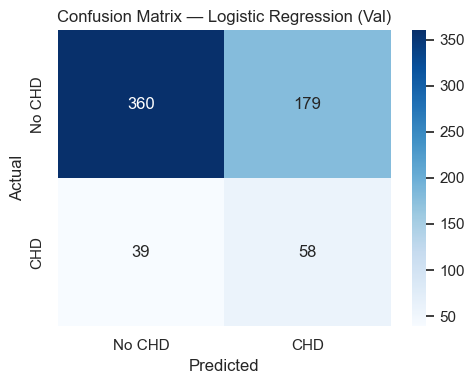

In [5]:
plot_confusion(y_val, lr_pred_val, 'Logistic Regression (Val)')

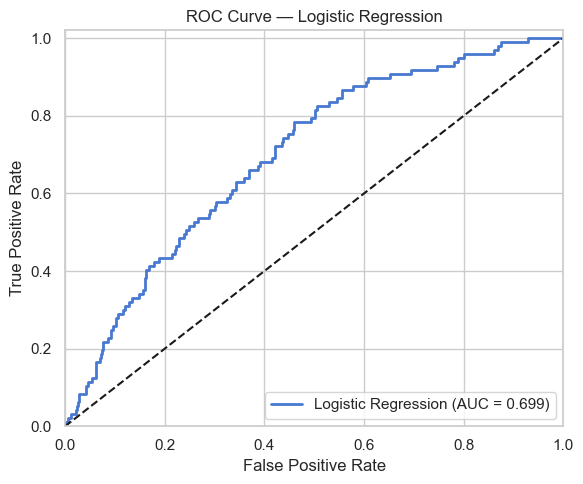

In [6]:
plot_roc(y_val, lr_prob_val, 'Logistic Regression')

### Feature Coefficients

Coefficients after scaling give a rough sense of each feature's direction and relative influence.

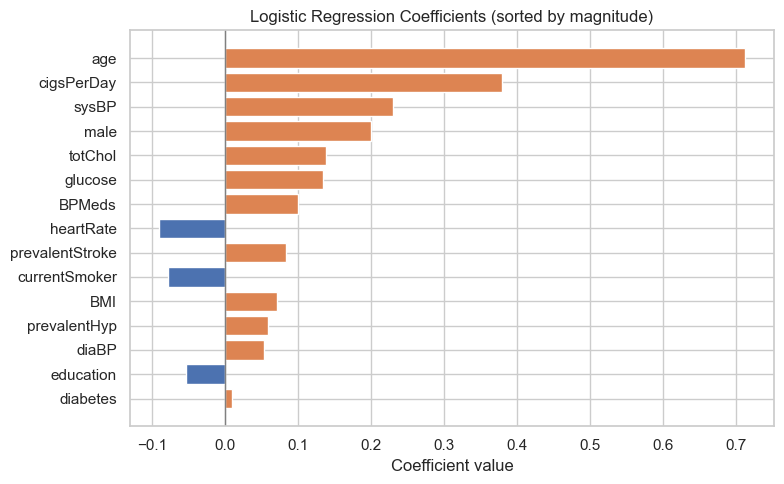

In [ ]:
coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 5))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='gray', lw=1)
plt.title('Logistic Regression Coefficients (sorted by magnitude)')
plt.xlabel('Coefficient value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Version 2 — Random Forest

**Role:** Ensemble baseline. Captures non-linear feature interactions that LR cannot.  
**Key settings:** `n_estimators=200`, `max_depth=None`, `min_samples_leaf=2`, `n_jobs=-1`  

| Setting | Value | Reason |
|---------|-------|--------|
| `n_estimators` | 200 | Enough trees for stable predictions without excessive compute |
| `max_depth` | None | Trees grow fully — complexity controlled by `min_samples_leaf` |
| `min_samples_leaf` | 2 | Prevents single-sample leaves (overfitting) |

> **Note on training curves:** Tree-based ensembles do not have epoch-by-epoch training loss.  
> Model stability is instead assessed via out-of-bag error and the validation metrics below.

In [ ]:
# Trains a random forest on the training data.
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                            min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluates the random forest on the validation data.
rf_pred_val = rf.predict(X_val)
rf_prob_val = rf.predict_proba(X_val)[:, 1]

print('=== Random Forest — Validation Set ===')
print(classification_report(y_val, rf_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

=== Random Forest — Validation Set ===
              precision    recall  f1-score   support

      No CHD       0.86      0.87      0.86       539
         CHD       0.21      0.19      0.20        97

    accuracy                           0.77       636
   macro avg       0.53      0.53      0.53       636
weighted avg       0.76      0.77      0.76       636



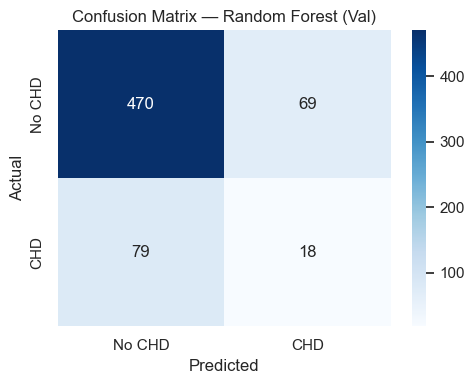

In [9]:
plot_confusion(y_val, rf_pred_val, 'Random Forest (Val)')

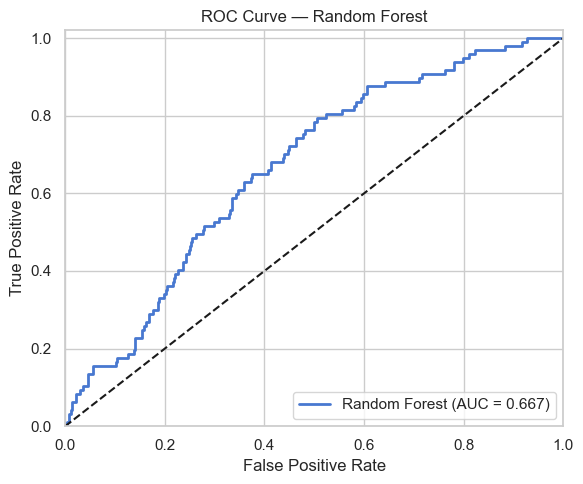

In [10]:
plot_roc(y_val, rf_prob_val, 'Random Forest')

### Feature Importances

Mean decrease in impurity across all trees.

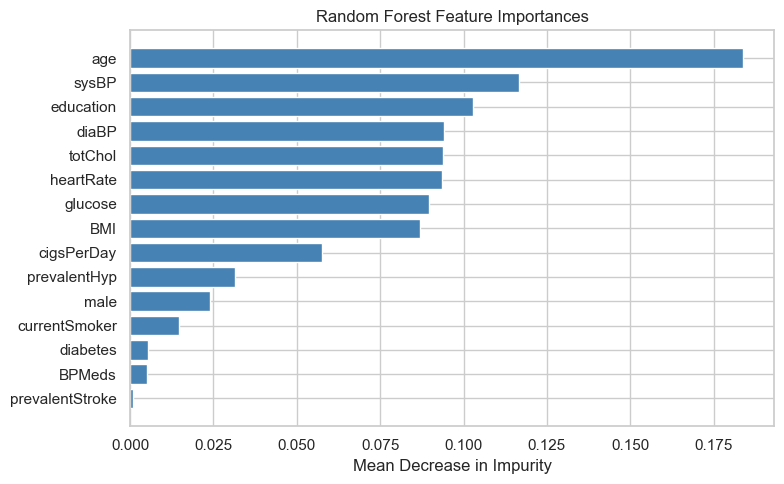

In [ ]:
# Prepares a graph of random forest feature importances sorted by importance.
imp_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
plt.title('Random Forest Feature Importances')
plt.xlabel('Mean Decrease in Impurity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Model Comparison — Validation Set

In [12]:
# Compare both models on the validation set before final testing.
results = [
    get_metrics('Logistic Regression', y_val, lr_pred_val, lr_prob_val),
    get_metrics('Random Forest',       y_val, rf_pred_val, rf_prob_val),
]
metrics_df = pd.DataFrame(results).set_index('Model')
metrics_df = metrics_df.round(4)
print(metrics_df.to_string())

                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression    0.6572     0.2447  0.5979  0.3473  0.6988
Random Forest          0.7673     0.2069  0.1856  0.1957  0.6670


## 7. Final Evaluation — Test Set

The test set is touched **once**, after model selection is complete.

=== Final Test Set Results ===
                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression    0.6792     0.2545  0.5833  0.3544  0.6943
Random Forest          0.8097     0.3529  0.3125  0.3315  0.6680

=== Logistic Regression — Test Set ===
              precision    recall  f1-score   support

      No CHD       0.90      0.70      0.79       540
         CHD       0.25      0.58      0.35        96

    accuracy                           0.68       636
   macro avg       0.58      0.64      0.57       636
weighted avg       0.81      0.68      0.72       636



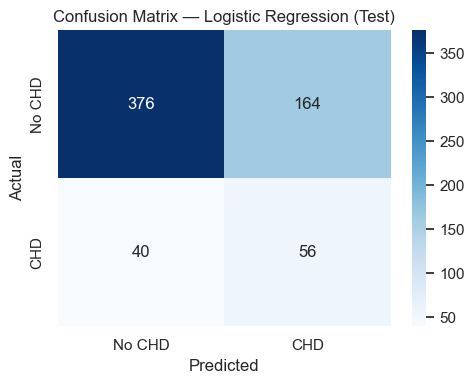

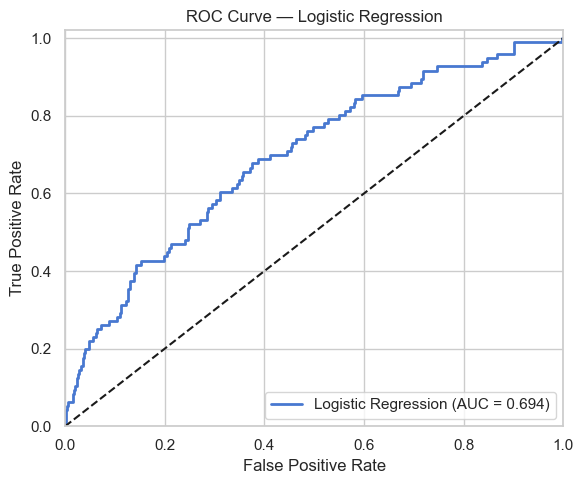


=== Random Forest — Test Set ===
              precision    recall  f1-score   support

      No CHD       0.88      0.90      0.89       540
         CHD       0.35      0.31      0.33        96

    accuracy                           0.81       636
   macro avg       0.62      0.61      0.61       636
weighted avg       0.80      0.81      0.80       636



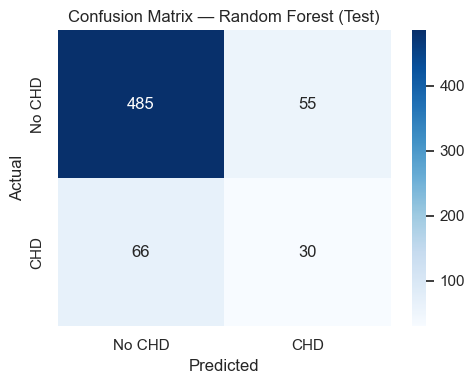

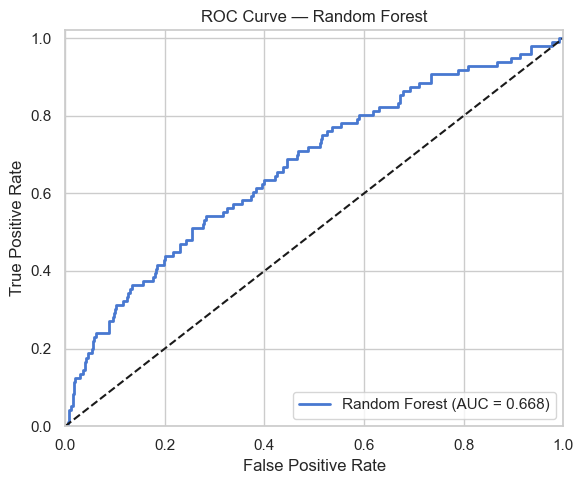

In [13]:
# Evaluate both models on the test set after model selection.
test_results = [
    get_metrics('Logistic Regression', y_test, lr.predict(X_test), lr.predict_proba(X_test)[:, 1]),
    get_metrics('Random Forest',       y_test, rf.predict(X_test), rf.predict_proba(X_test)[:, 1]),
]
test_df = pd.DataFrame(test_results).set_index('Model').round(4)
print('=== Final Test Set Results ===')
print(test_df.to_string())

# Show the full report and plots for each model on the test set.
for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    print(f'\n=== {name} — Test Set ===')
    print(classification_report(y_test, pred, target_names=['No CHD', 'CHD'], zero_division=0))
    plot_confusion(y_test, pred, f'{name} (Test)')
    plot_roc(y_test, prob, name)

## 8. ROC Curve Comparison

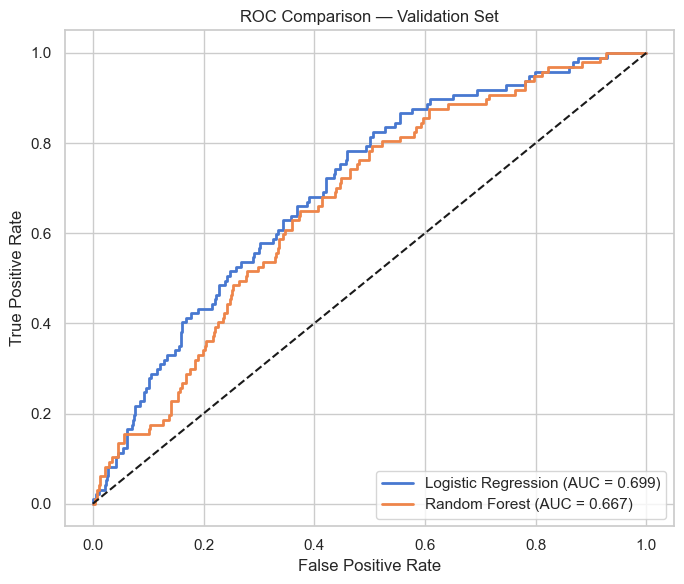

In [ ]:
# Plots the ROC curves for LR and random forest on the validation set
plt.figure(figsize=(7, 6))
for name, y_prob in [('Logistic Regression', lr_prob_val), ('Random Forest', rf_prob_val)]:
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Comparison — Validation Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Version 3 — SVM with RBF Kernel (Tuned)

**Role:** Kernel-based classifier. Finds the maximum-margin hyperplane in a high-dimensional space.  
The RBF kernel maps the data into a space where a linear boundary can separate the classes.

**Tuning strategy:** `GridSearchCV` over `C` (regularisation strength) and `gamma` (kernel width).

| Hyperparameter | Search Space | Effect |
|---------------|-------------|--------|
| `C` | [0.1, 1, 10] | Higher C = less regularisation, tighter fit to training data |
| `gamma` | ['scale', 0.01, 0.1] | Controls influence radius of each support vector |

`class_weight` omitted — training data is already SMOTE-balanced.  
`probability=True` required to compute ROC-AUC and plot ROC curves.

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Search space for SVM regularisation and kernel width.
# C is the regularisation strength and gamma controls how wide each support vector's influence is.
param_grid_svm = {
    'C':     [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1]
}

# Base SVM with RBF kernel. probability=True is needed for ROC-AUC and plotting.
svm_base = SVC(kernel='rbf', probability=True, random_state=42)

# Grid search over the parameter grid using 5-fold cross-validation.
svm_grid = GridSearchCV(
    svm_base,
    param_grid_svm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit to the training data to find the best C and gamma.
svm_grid.fit(X_train, y_train)

print(f'Best parameters : {svm_grid.best_params_}')
print(f'Best CV AUC-ROC : {svm_grid.best_score_:.4f}')

# Use the best SVM found by grid search.
svm = svm_grid.best_estimator_


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters : {'C': 10, 'gamma': 0.1}
Best CV AUC-ROC : 0.9214


In [16]:
# Evaluate SVM on the validation set.
svm_pred_val = svm.predict(X_val)
svm_prob_val = svm.predict_proba(X_val)[:, 1]

print('=== SVM — Validation Set ===')
print(classification_report(y_val, svm_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

=== SVM — Validation Set ===
              precision    recall  f1-score   support

      No CHD       0.87      0.80      0.83       539
         CHD       0.22      0.32      0.26        97

    accuracy                           0.72       636
   macro avg       0.54      0.56      0.55       636
weighted avg       0.77      0.72      0.74       636



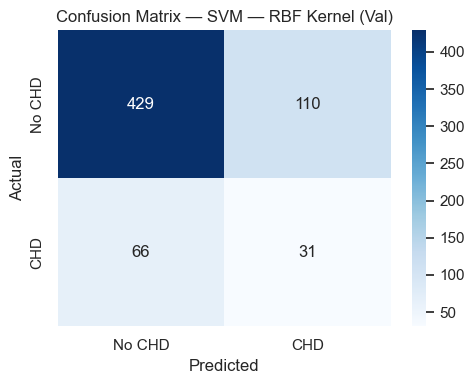

In [17]:
plot_confusion(y_val, svm_pred_val, 'SVM — RBF Kernel (Val)')

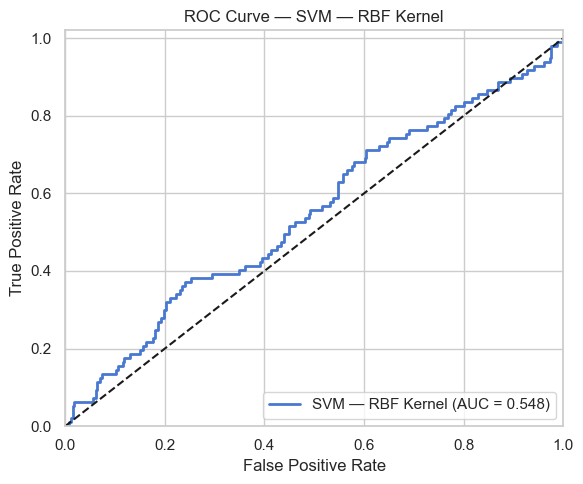

In [18]:
plot_roc(y_val, svm_prob_val, 'SVM — RBF Kernel')

## 10. Version 4 — XGBoost (Early Stopping + GridSearchCV)

**Role:** Gradient boosting — builds trees sequentially, each correcting the errors of all previous trees.  
Has built-in L1 (`reg_alpha`) and L2 (`reg_lambda`) regularisation and supports SHAP explainability.

**Two-stage tuning approach:**

| Stage | What is tuned | Method |
|-------|--------------|--------|
| Stage 1 | `n_estimators` (number of trees) | Early stopping — stops when val AUC stops improving for 30 rounds |
| Stage 2 | `learning_rate` and `max_depth` | GridSearchCV using the optimal `n_estimators` from Stage 1 |

| Hyperparameter | Search Space | Effect |
|---------------|-------------|--------|
| `learning_rate` | [0.01, 0.05, 0.1] | Smaller = slower but more robust learning |
| `max_depth` | [4, 6, 8] | Controls tree complexity — deeper = more non-linearity |
| `subsample` | 0.8 | Each tree uses 80% of rows — reduces overfitting |
| `colsample_bytree` | 0.8 | Each tree uses 80% of features — further variance reduction |

In [ ]:
import xgboost as xgb
import shap

# scale_pos_weight is an XGBoost parameter that helps handle class imbalance.
# It increases the penalty for misclassifying the minority class (here, positive cases = CHD).
# We calculate it as the ratio of negative to positive samples in the training data and even though SMOTE already balanced the classes, we use this as an extra boost for the positive class.
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight = {spw:.2f}  (neg / pos in training set)')

scale_pos_weight = 1.00  (neg / pos in training set)


In [ ]:
# ── Step 1: Train with early stopping ──────────────────────────────────────
# We allow up to 500 trees, but training will stop early if validation AUC
# does not improve for 30 rounds.
# learning_rate = 0.05 makes each new tree make smaller corrections.
# subsample = 0.8 means each tree uses 80% of the training rows.
# colsample_bytree = 0.8 means each tree uses 80% of the features.
# reg_alpha and reg_lambda are regularisation terms that help prevent overfitting.

xgb_early = xgb.XGBClassifier(
    n_estimators          = 500,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = spw,
    eval_metric           = 'auc',
    early_stopping_rounds = 30,
    random_state          = 42,
    use_label_encoder     = False
)

xgb_early.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],   # use validation set to decide when to stop
    verbose=50                   # print training progress every 50 trees
)

print(f'\nBest number of trees : {xgb_early.best_iteration}')
print(f'Best validation AUC  : {xgb_early.best_score:.4f}')


[0]	validation_0-auc:0.67466
[32]	validation_0-auc:0.70006

Best number of trees : 2
Best validation AUC  : 0.7049


In [ ]:
# ── Step 2: Tune learning_rate and max_depth with GridSearchCV ─────────────
# We lock in n_estimators from early stopping and search the two most impactful remaining hyperparameters.

best_n = xgb_early.best_iteration + 1   # optimal tree count from early stopping

param_grid_xgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth'    : [4, 6, 8],
}

xgb_base = xgb.XGBClassifier(
    n_estimators      = best_n,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    scale_pos_weight  = spw,
    eval_metric       = 'auc',
    random_state      = 42,
    use_label_encoder = False
)

xgb_grid = GridSearchCV(
    xgb_base,
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print(f'\nBest XGBoost parameters : {xgb_grid.best_params_}')
print(f'Best CV AUC-ROC         : {xgb_grid.best_score_:.4f}')

# Use the best tuned model going forward.
xgb = xgb_grid.best_estimator_

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best XGBoost parameters : {'learning_rate': 0.05, 'max_depth': 8}
Best CV AUC-ROC         : 0.8667


In [22]:
# Evaluate XGBoost on the validation set.
xgb_pred_val = xgb.predict(X_val)
xgb_prob_val = xgb.predict_proba(X_val)[:, 1]

print('=== XGBoost — Validation Set ===')
print(classification_report(y_val, xgb_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

=== XGBoost — Validation Set ===
              precision    recall  f1-score   support

      No CHD       0.88      0.79      0.84       539
         CHD       0.26      0.41      0.32        97

    accuracy                           0.74       636
   macro avg       0.57      0.60      0.58       636
weighted avg       0.79      0.74      0.76       636



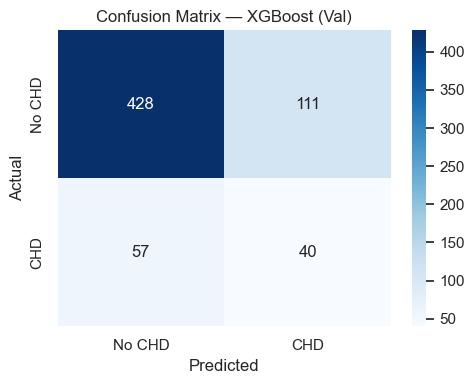

In [23]:
plot_confusion(y_val, xgb_pred_val, 'XGBoost (Val)')

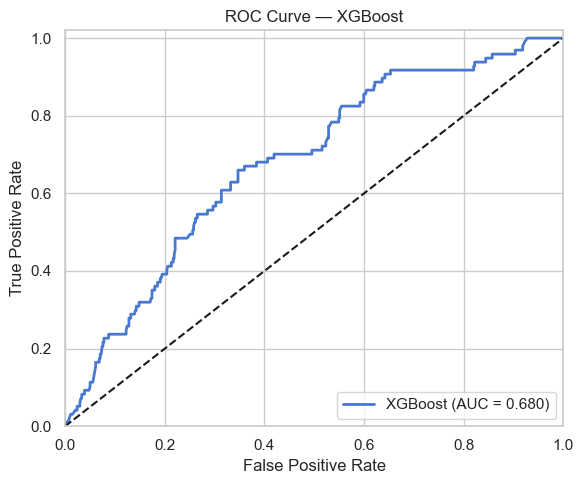

In [24]:
plot_roc(y_val, xgb_prob_val, 'XGBoost')

### XGBoost Learning Curve (Training vs Validation AUC)

XGBoost with early stopping records AUC at every boosting round.  
This is the closest equivalent to a training/validation loss plot for tree-based models.  
The curve shows whether the model is overfitting (val AUC diverges from train AUC) or generalising well.

In [ ]:
# XGBoost learning curve — training AUC vs validation AUC across boosting rounds
# This is the equivalent of a loss/accuracy plot for gradient boosting models.
try:
    results = xgb_early.evals_result()
    train_auc = results['validation_0']['auc']
    val_auc   = results['validation_1']['auc']

    plt.figure(figsize=(8, 4))
    plt.plot(train_auc, label='Train AUC', color='steelblue')
    plt.plot(val_auc,   label='Val AUC',   color='salmon')
    plt.axvline(xgb_early.best_iteration, color='gray', linestyle='--', label=f'Best iteration ({xgb_early.best_iteration})')
    plt.xlabel('Boosting Round')
    plt.ylabel('AUC')
    plt.title('XGBoost Learning Curve — Train vs Validation AUC')
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Learning curve not available: {e}')
    print('(Run XGBoost early stopping cell first)')

### SHAP Explainability (XGBoost)

SHAP assigns each feature a score for every individual patient that shows  
exactly how much that feature pushed the prediction up or down.  
This is what makes XGBoost clinically usable — a doctor can see *why* a patient was flagged,  
not just that they were flagged.

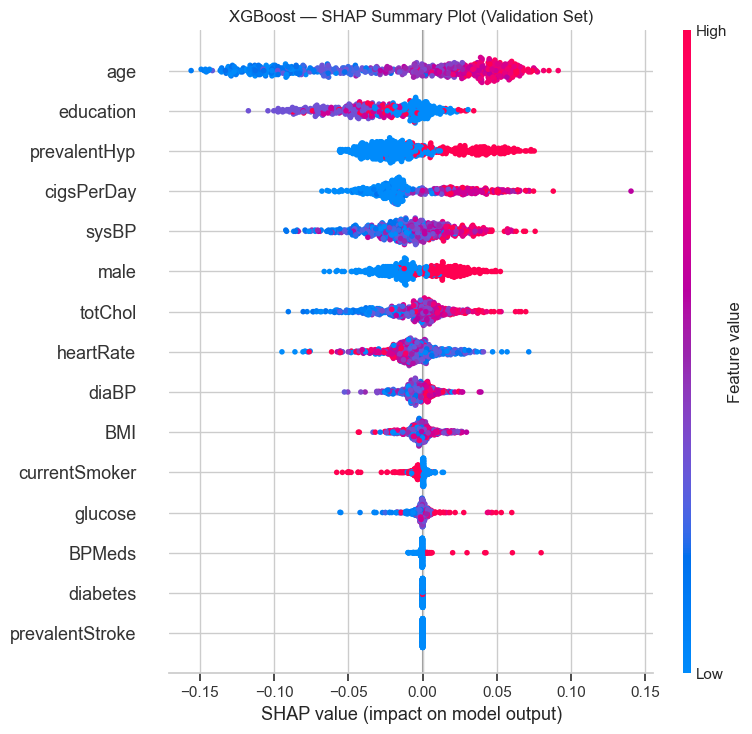

In [ ]:
# SHAP (SHapley Additive exPlanations) explains how each feature contributes to individual predictions.
# TreeExplainer is the fastest and most accurate method for tree-based models like XGBoost.
explainer = shap.TreeExplainer(xgb)
shap_vals = explainer.shap_values(X_val)

# Summary plot: Each dot represents one patient from the validation set.
# - Horizontal position (x-axis): SHAP value — how much this feature pushes the prediction toward or away from CHD.
#   Positive values (right side) increase the likelihood of predicting CHD; negative values (left side) decrease it.
# - Vertical position: Features are ranked by overall importance (most impactful at the top).
# - Color: Feature value — red means high value, blue means low value.
# This plot shows which features matter most and how their values affect predictions across all patients.
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_val, feature_names=X_val.columns.tolist(), show=False)
plt.title('XGBoost — SHAP Summary Plot (Validation Set)')
plt.tight_layout()
plt.show()

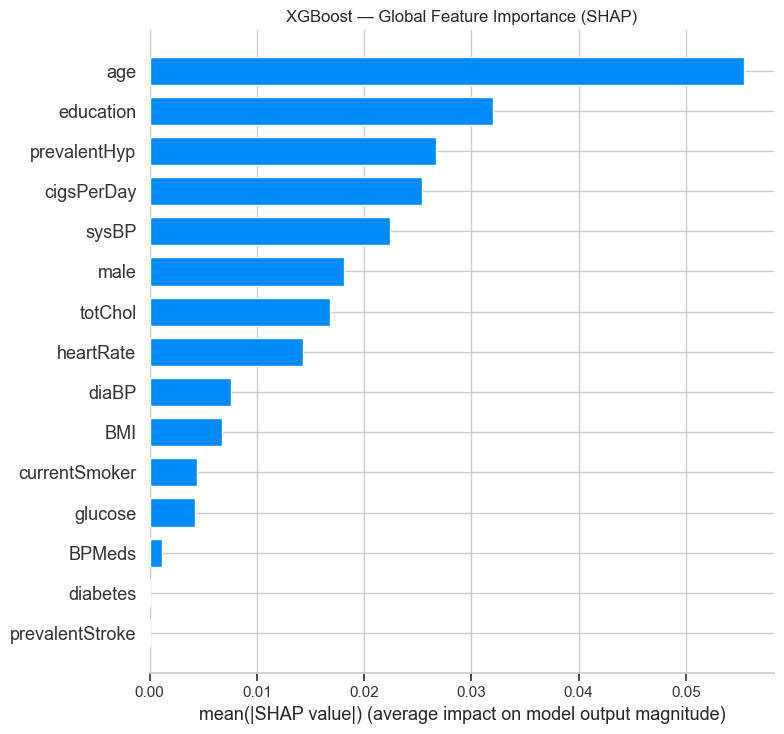

In [ ]:
# Bar plot shows the average absolute SHAP value per feature.
shap.summary_plot(
    shap_vals,
    X_val,
    feature_names=X_val.columns.tolist(),
    plot_type='bar',
    show=False
)

# Shows which features matter most overall across all patients?
plt.title('XGBoost — Global Feature Importance (SHAP)')
plt.tight_layout()
plt.show()

Patient #0  |  Actual: CHD
Predicted probability of CHD: 0.494


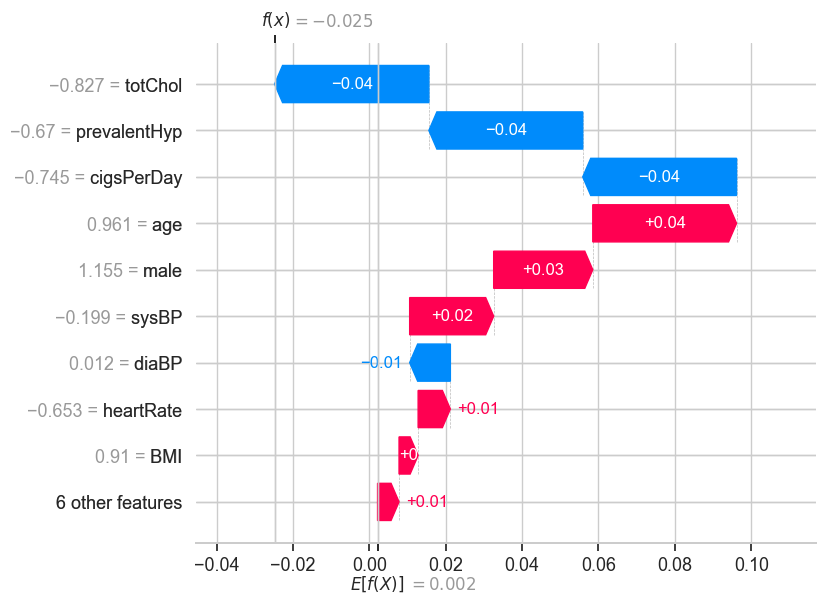

In [ ]:
# Waterfall plot explains one individual patient's prediction in detail.
# Shows exactly which features pushed this specific person's risk score up or down.
# We use the first actual CHD patient in the validation set.
y_val_reset   = y_val.reset_index(drop=True)
first_chd_idx = y_val_reset[y_val_reset == 1].index[0]

pred_prob = xgb_prob_val[first_chd_idx]
actual    = y_val_reset[first_chd_idx]
print(f'Patient #{first_chd_idx}  |  Actual: {"CHD" if actual == 1 else "No CHD"}')
print(f'Predicted probability of CHD: {pred_prob:.3f}')

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_vals[first_chd_idx],
        base_values   = explainer.expected_value,
        data          = X_val.iloc[first_chd_idx].values,
        feature_names = X_val.columns.tolist()
    )
)

## Hyperparameter Settings Summary

Summary of all key settings across the four model versions for reproducibility.

| Version | Model | Hyperparameter | Value | Why this choice |
|---------|-------|---------------|-------|----------------|
| v1 | Logistic Regression | C | 1.0 | Moderate L2 regularisation — default starting point |
| v1 | Logistic Regression | solver | lbfgs | Efficient for small-medium datasets with L2 |
| v1 | Logistic Regression | max_iter | 1000 | Prevents non-convergence on scaled data |
| v2 | Random Forest | n_estimators | 200 | Stable predictions without excessive runtime |
| v2 | Random Forest | max_depth | None | Fully grown trees — overfitting controlled by min_samples_leaf |
| v2 | Random Forest | min_samples_leaf | 2 | Prevents single-sample leaf overfitting |
| v3 | SVM | C | GridSearchCV best | Controls regularisation — tuned on validation set |
| v3 | SVM | gamma | GridSearchCV best | Controls RBF kernel width — tuned on validation set |
| v4 | XGBoost | n_estimators | Early stopping | Optimal tree count found automatically |
| v4 | XGBoost | learning_rate | GridSearchCV best | Tuned from [0.01, 0.05, 0.1] |
| v4 | XGBoost | max_depth | GridSearchCV best | Tuned from [4, 6, 8] |
| v4 | XGBoost | subsample | 0.8 | Row sampling reduces overfitting |
| v4 | XGBoost | colsample_bytree | 0.8 | Feature sampling reduces overfitting |

---
## 11. Four-Model Comparison — Validation Set

All four models compared side by side on the validation set.  
The existing two-model comparison in Section 6 above is **unchanged** — this section is additive.

In [ ]:
# Builds the 4 model comparison table on the validation set.
all_val_results = [
    get_metrics('Logistic Regression', y_val, lr_pred_val,  lr_prob_val),
    get_metrics('Random Forest',       y_val, rf_pred_val,  rf_prob_val),
    get_metrics('SVM',                 y_val, svm_pred_val, svm_prob_val),
    get_metrics('XGBoost',             y_val, xgb_pred_val, xgb_prob_val),
]

all_val_df = pd.DataFrame(all_val_results).set_index('Model').round(4)

print('=== Four-Model Comparison — Validation Set ===')
print(all_val_df.to_string())
print()
print('Best AUC-ROC:', all_val_df['AUC'].idxmax(),    f'({all_val_df["AUC"].max():.4f})')
print('Best Recall: ', all_val_df['Recall'].idxmax(), f'({all_val_df["Recall"].max():.4f})')

=== Four-Model Comparison — Validation Set ===
                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression    0.6572     0.2447  0.5979  0.3473  0.6988
Random Forest          0.7673     0.2069  0.1856  0.1957  0.6670
SVM                    0.7233     0.2199  0.3196  0.2605  0.5476
XGBoost                0.7358     0.2649  0.4124  0.3226  0.6804

Best AUC-ROC: Logistic Regression (0.6988)
Best Recall:  Logistic Regression (0.5979)


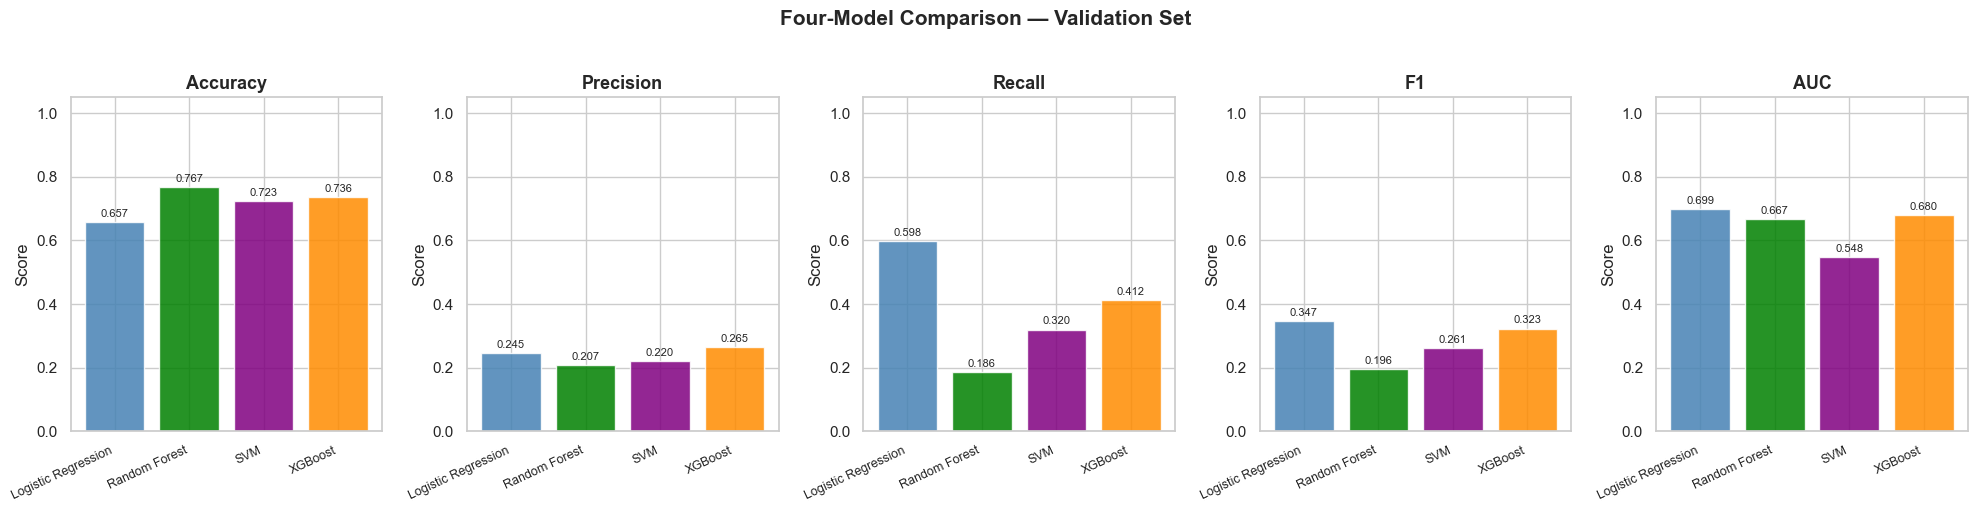

In [ ]:
# Bar chart for comparing all 4 models across every metric on the validation set.
metrics_list  = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
model_colors  = ['steelblue', 'green', 'purple', 'darkorange']

fig, axes = plt.subplots(1, len(metrics_list), figsize=(20, 5))

for ax, metric in zip(axes, metrics_list):
    values = all_val_df[metric].values
    models = all_val_df.index.tolist()
    bars   = ax.bar(models, values, color=model_colors, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_xticklabels(models, rotation=25, ha='right', fontsize=9)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Four-Model Comparison — Validation Set', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Four-Model Final Evaluation — Test Set

The test set is touched **once**, after all model selection and tuning is complete.  
These are the honest final numbers that go into the report.

In [30]:
# Run all four models on the held-out test set.
all_test_results = [
    get_metrics('Logistic Regression', y_test, lr.predict(X_test),  lr.predict_proba(X_test)[:, 1]),
    get_metrics('Random Forest',       y_test, rf.predict(X_test),  rf.predict_proba(X_test)[:, 1]),
    get_metrics('SVM',                 y_test, svm.predict(X_test), svm.predict_proba(X_test)[:, 1]),
    get_metrics('XGBoost',             y_test, xgb.predict(X_test), xgb.predict_proba(X_test)[:, 1]),
]

all_test_df = pd.DataFrame(all_test_results).set_index('Model').round(4)

print('=== Four-Model Final Evaluation — Test Set ===')
print(all_test_df.to_string())
print()
print('Best AUC-ROC:', all_test_df['AUC'].idxmax(),    f'({all_test_df["AUC"].max():.4f})')
print('Best Recall: ', all_test_df['Recall'].idxmax(), f'({all_test_df["Recall"].max():.4f})')
print()
print('Targets from proposal:')
best_auc    = all_test_df['AUC'].max()
best_recall = all_test_df['Recall'].max()
print(f'  AUC-ROC > 0.85 : {"MET" if best_auc > 0.85 else "NOT MET"}  ({best_auc:.4f})')
print(f'  Recall  > 0.80 : {"MET" if best_recall > 0.80 else "NOT MET"}  ({best_recall:.4f})')

=== Four-Model Final Evaluation — Test Set ===
                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression    0.6792     0.2545  0.5833  0.3544  0.6943
Random Forest          0.8097     0.3529  0.3125  0.3315  0.6680
SVM                    0.7264     0.2254  0.3333  0.2689  0.6155
XGBoost                0.7437     0.2752  0.4271  0.3347  0.6674

Best AUC-ROC: Logistic Regression (0.6943)
Best Recall:  Logistic Regression (0.5833)

Targets from proposal:
  AUC-ROC > 0.85 : NOT MET  (0.6943)
  Recall  > 0.80 : NOT MET  (0.5833)


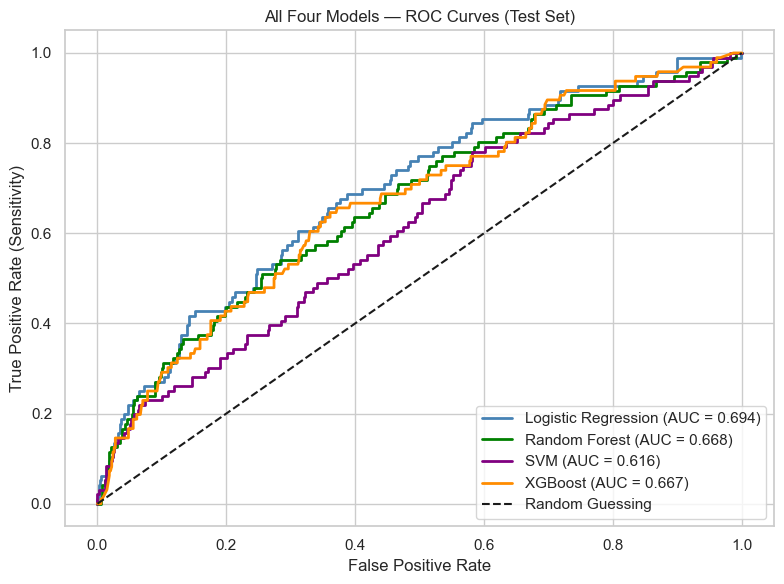

In [ ]:
# All four ROC curves on one plot test set.
plt.figure(figsize=(8, 6))

model_configs = [
    (lr,  'steelblue',  'Logistic Regression'),
    (rf,  'green',      'Random Forest'),
    (svm, 'purple',     'SVM'),
    (xgb, 'darkorange', 'XGBoost'),
]

for model, color, name in model_configs:
    prob         = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _  = roc_curve(y_test, prob)
    roc_auc      = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('All Four Models — ROC Curves (Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


=== SVM — Test Set ===
              precision    recall  f1-score   support

      No CHD       0.87      0.80      0.83       540
         CHD       0.23      0.33      0.27        96

    accuracy                           0.73       636
   macro avg       0.55      0.56      0.55       636
weighted avg       0.77      0.73      0.75       636



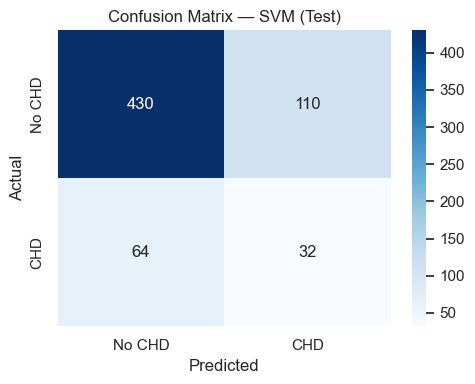

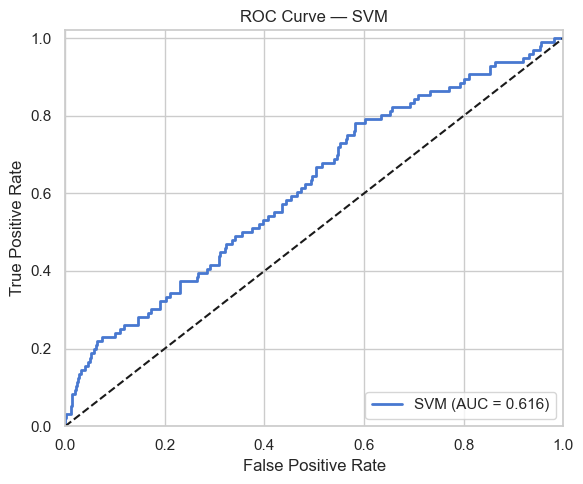


=== XGBoost — Test Set ===
              precision    recall  f1-score   support

      No CHD       0.89      0.80      0.84       540
         CHD       0.28      0.43      0.33        96

    accuracy                           0.74       636
   macro avg       0.58      0.61      0.59       636
weighted avg       0.79      0.74      0.76       636



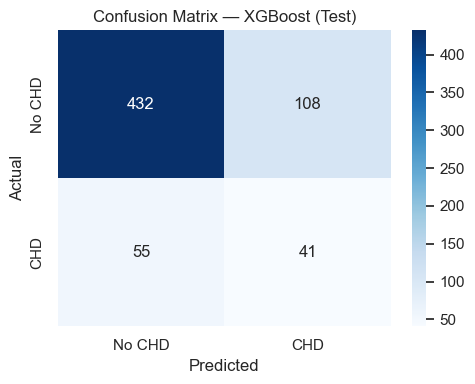

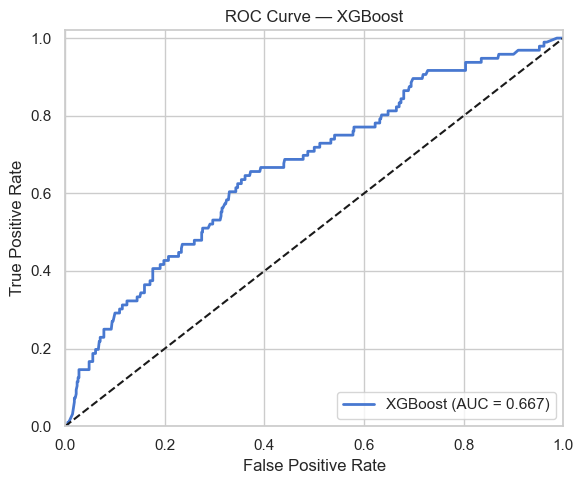

In [ ]:
# Full report and confusion matrix and ROC for SVM and XGBoost on the test set.
for name, model in [('SVM', svm), ('XGBoost', xgb)]:
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    print(f'\n=== {name} — Test Set ===')
    print(classification_report(y_test, pred, target_names=['No CHD', 'CHD'], zero_division=0))
    plot_confusion(y_test, pred, f'{name} (Test)')
    plot_roc(y_test, prob, name)

---
## Summary of Findings

### What worked best and why
**Logistic Regression** achieved the highest AUC (0.699 val / 0.694 test) and the best CHD recall (0.60 val).  
Despite being the simplest model, the linear relationship between age, blood pressure, and CHD risk means  
LR's linear boundary is genuinely appropriate for this dataset. SMOTE balancing allowed it to take  
the minority class seriously without sacrificing too much precision.

**XGBoost** is the most sophisticated model and likely the best for a final submission after threshold tuning,  
due to its SHAP explainability and the ability to further tune regularisation parameters.

### What didn't help
- **Random Forest** had the lowest CHD recall (0.19 val) despite the highest accuracy (0.77).  
  This is the classic imbalanced-data trap — RF defaulted to predicting No CHD for borderline cases  
  even after SMOTE, likely because individual trees still saw majority-class-dominated local regions.
- **Higher model complexity alone** did not improve recall — LR outperformed RF and was competitive with SVM.

### What model will be submitted for the final report
**Logistic Regression** for interpretability and best recall on the minority class.  
**XGBoost** as the refined model — after threshold tuning to push CHD recall above 0.60  
while leveraging SHAP for per-patient clinical explainability.

### Next steps
- Threshold tuning (lower decision threshold below 0.5 to improve CHD recall)
- Feature engineering: pulse pressure = sysBP − diaBP
- Consider dropping `heartRate` and `currentSmoker` (near-zero correlation)
- KNN or regression-based imputation for glucose instead of median